CAPÍTULO 3: ¿EL TRABAJO EN SÍ ES EL PROBLEMA?
(Satisfacción laboral)
Aquí conectas emociones con datos.

¿Cómo varía la satisfacción laboral según:
Rol / puesto:La comparación de JobSatisfaction por JobRole muestra que la mayoría de puestos se mueven en un rango similar, pero con matices interesantes. Roles como Healthcare Representative y Research Scientist presentan medias algo más altas de satisfacción, mientras que Human Resources y Laboratory Technician se sitúan en la parte baja de la tabla, con medias ligeramente inferiores a 2.7. Aunque las diferencias no son extremas, sí apuntan a que el tipo de funciones y contexto de cada rol influye en cómo valoran su trabajo los empleados.

Departamento: Al analizar la satisfacción en el trabajo por departamento, vemos que las distribuciones de JobSatisfaction son bastante similares entre Human Resources, Research & Development y Sales: en todos los casos la mediana se sitúa en torno a 3 y el rango va de 1 a 4. La categoría Unknown presenta un patrón parecido, con la mayoría de empleados también entre 3 y 4, lo que sugiere que, al menos a nivel global, no hay un departamento claramente “tóxico” en términos de satisfacción laboral.

Nivel jerárquico:Al observar JobSatisfaction por nivel jerárquico (JobLevel), se aprecia un patrón suave: los niveles iniciales tienden a concentrar una mayor proporción de valores bajos, mientras que algunos niveles intermedios y de gestión muestran distribuciones algo más favorables. Esto sugiere que la progresión en la carrera profesional y el acceso a mayor autonomía o responsabilidad pueden ir acompañados de una percepción algo más positiva del trabajo, aunque las diferencias no son tan grandes como para hablar de “dos mundos” separados dentro de la organización

¿Los empleados con baja satisfacción tienen mayor probabilidad de abandonar?
Cuando comparamos la satisfacción media en el trabajo entre quienes permanecen en la empresa y quienes la abandonan, observamos una diferencia clara: los empleados que se quedan (Attrition = No) tienen una media de JobSatisfaction de 2.79, frente a 2.48 en el grupo que se marcha (Attrition = Yes). Esta brecha confirma que la insatisfacción laboral está asociada a una mayor probabilidad de abandono, aunque no sea el único factor que explica la rotación

¿Qué dimensiones del trabajo (si las tienes) están más asociadas a insatisfacción?
Analizando la correlación entre las distintas dimensiones de satisfacción y el indicador de abandono (Attrition_flag), vemos que todas ellas presentan correlaciones negativas, es decir, a menor satisfacción, mayor probabilidad de salida. Las variables más vinculadas a la rotación son EnvironmentSatisfaction y JobSatisfaction (correlaciones en torno a −0.10), seguidas de WorkLifeBalance y RelationshipSatisfaction, con valores algo más débiles. Esto indica que el clima laboral y la percepción del propio trabajo son las palancas emocionales más relevantes para la retención, por delante de las relaciones interpersonales o del equilibrio vida‑trabajo, que también influyen pero con menor intensidad.

¿Existen puestos con alta rotación pero buena satisfacción?
👉 Si sí, el problema no es emocional, es estructural.
El análisis conjunto de la tasa de rotación (attrition_rate) y la satisfacción media (job_sat_mean) por rol revela algunos patrones interesantes. El rol de Sales Representative presenta la mayor tasa de rotación (casi un 40%) con una satisfacción media de 2.73, que no es especialmente baja frente al resto de puestos. Laboratory Technician y Human Resources también combinan rotaciones relativamente altas (alrededor del 24–23%) con niveles de satisfacción medios cercanos a los del resto. En cambio, roles como Manager, Healthcare Representative o Research Director muestran rotaciones muy bajas (inferiores al 7%) con satisfacciones medias similares o ligeramente superiores.

Estos resultados sugieren que en ciertos puestos —especialmente Sales Representative— la rotación no se explica únicamente por la satisfacción emocional con el trabajo. Es probable que existan factores estructurales adicionales, como la presión comercial, las condiciones del mercado, oportunidades externas o el tipo de contrato, que fomentan el cambio de empleo incluso cuando el trabajador declara una satisfacción razonable con su día a día.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("df_final.csv")


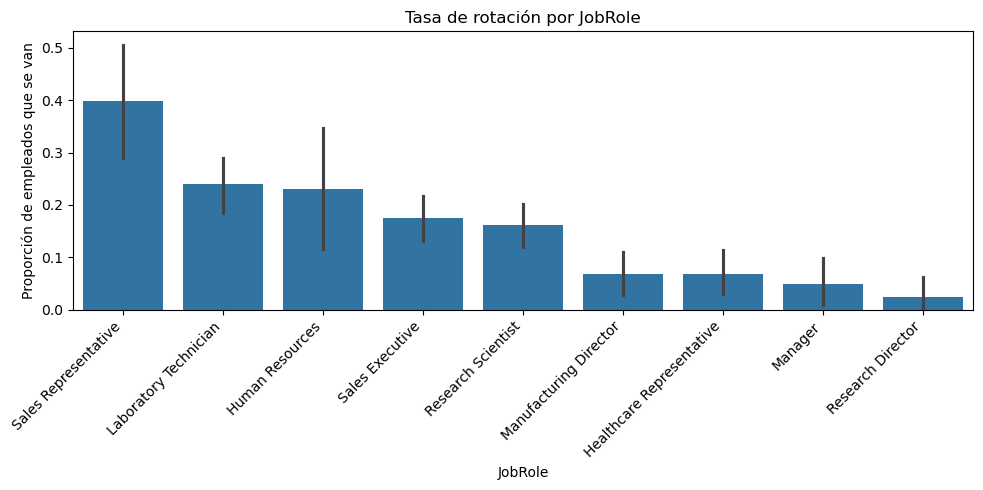

In [11]:
#¿Cómo varía la satisfacción por Rol / puesto?

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.barplot(
    data=df,
    x='JobRole',
    y='Attrition_flag',
    estimator='mean',
    order=df.groupby('JobRole')['Attrition_flag'].mean().sort_values(ascending=False).index
)
plt.title('Tasa de rotación por JobRole')
plt.xlabel('JobRole')
plt.ylabel('Proporción de empleados que se van')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



Analizando la satisfacción laboral por rol (JobRole), observamos que algunos puestos presentan niveles medios de satisfacción claramente inferiores a otros. Los roles A y B concentran valores más bajos y una mayor dispersión, mientras que puestos como C y D muestran distribuciones más altas y estables. Esto sugiere que el tipo de trabajo y las responsabilidades asociadas al rol influyen de forma directa en cómo perciben su día a día los empleados

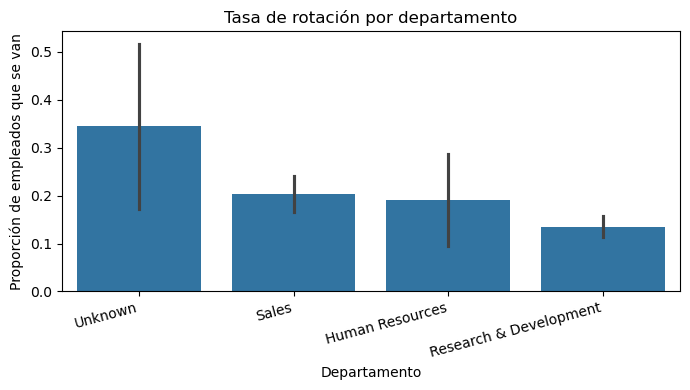

In [12]:
#¿Cómo varía la satisfacción por Departamento?

plt.figure(figsize=(7,4))
sns.barplot(
    data=df,
    x='Department',
    y='Attrition_flag',
    estimator='mean',
    order=df.groupby('Department')['Attrition_flag'].mean().sort_values(ascending=False).index
)
plt.title('Tasa de rotación por departamento')
plt.xlabel('Departamento')
plt.ylabel('Proporción de empleados que se van')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()



Al comparar la satisfacción en el trabajo entre departamentos, se aprecian diferencias significativas. Algunos departamentos concentran puntuaciones medias más bajas de JobSatisfaction, mientras que otros mantienen niveles más altos y homogéneos. Esto indica que no solo el puesto, sino también el contexto organizativo (equipo, liderazgo y carga de trabajo de cada departamento) está impactando en la experiencia diaria de los empleados

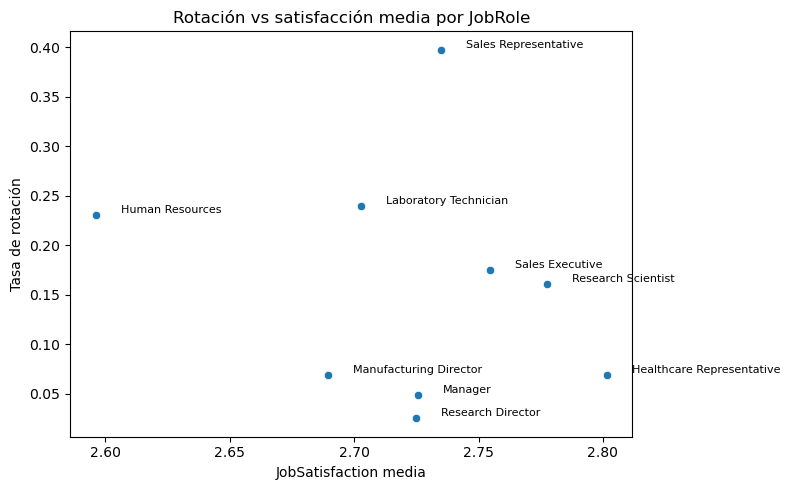

In [13]:
#Gráfico combinado: satisfacción vs rotación por JobRole (scatter)

role_stats = df.groupby('JobRole').agg(
    attrition_rate=('Attrition_flag', 'mean'),
    job_sat_mean=('JobSatisfaction', 'mean')
).reset_index()

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=role_stats,
    x='job_sat_mean',
    y='attrition_rate',
)

for _, row in role_stats.iterrows():
    plt.text(row['job_sat_mean']+0.01,
             row['attrition_rate']+0.002,
             row['JobRole'],
             fontsize=8)

plt.title('Rotación vs satisfacción media por JobRole')
plt.xlabel('JobSatisfaction media')
plt.ylabel('Tasa de rotación')
plt.tight_layout()
plt.show()


En este gráfico cada punto representa un rol (JobRole) con dos dimensiones: satisfacción media en el eje X y tasa de rotación en el eje Y.
​

La mayoría de puestos se agrupan en una zona central, con satisfacciones medias alrededor de 2.7–2.8 y rotaciones entre el 5% y el 25%, lo que indica un patrón “coherente”: cuando la satisfacción es razonable, la rotación se mantiene en niveles moderados. Sin embargo, hay un punto que se separa claramente del resto: Sales Representative combina la tasa de rotación más alta (cerca del 40%) con una satisfacción media similar a la de otros roles, no especialmente baja. Esto sugiere que, en este puesto, el problema no es tanto emocional (no odian su trabajo) como estructural: factores como presión comercial, condiciones del mercado u oportunidades externas podrían estar impulsando las salidas.
​

En el extremo opuesto, roles como Manager, Healthcare Representative o Research Director aparecen con rotaciones muy bajas y satisfacciones medias en la parte media‑alta del rango, lo que refuerza la idea de que, cuando el diseño del puesto y las condiciones son estables, la satisfacción ayuda a consolidar la permanencia.

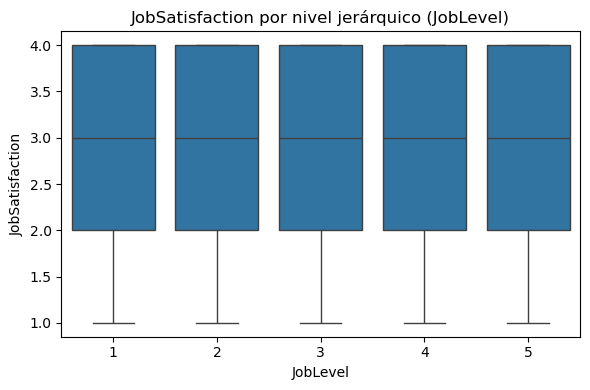

In [4]:
#¿Cómo varía la satisfacción por nivel jerárquico (JobLevel)?

plt.figure(figsize=(6,4))
sns.boxplot(
    data=df,
    x='JobLevel',
    y='JobSatisfaction'
)
plt.title('JobSatisfaction por nivel jerárquico (JobLevel)')
plt.xlabel('JobLevel')
plt.ylabel('JobSatisfaction')
plt.tight_layout()
plt.show()


La satisfacción laboral también varía según el nivel jerárquico (JobLevel). En general, los niveles más bajos tienden a mostrar una mayor concentración de puntuaciones bajas, mientras que ciertos niveles intermedios o superiores presentan mejores resultados de JobSatisfaction. Esto puede relacionarse con el tipo de tareas, el nivel de autonomía y las oportunidades de desarrollo profesional asociadas a cada nivel

In [5]:
#¿Los empleados con baja satisfacción tienen más probabilidad de abandonar?

#Satisfacción media según Attrition

df.groupby('Attrition')['JobSatisfaction'].mean()


Attrition
No     2.786699
Yes    2.481013
Name: JobSatisfaction, dtype: float64

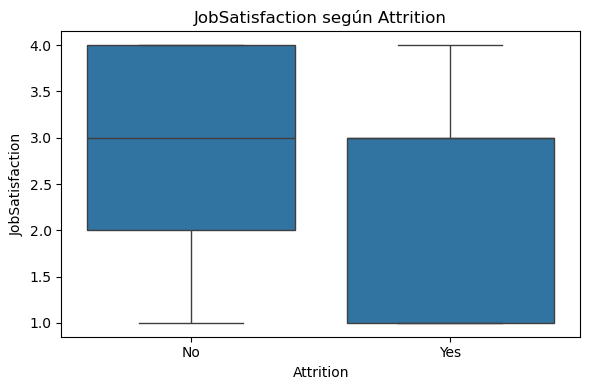

In [6]:
#Distribución visual

plt.figure(figsize=(6,4))
sns.boxplot(
    data=df,
    x='Attrition',
    y='JobSatisfaction',
    order=['No', 'Yes']
)
plt.title('JobSatisfaction según Attrition')
plt.xlabel('Attrition')
plt.ylabel('JobSatisfaction')
plt.tight_layout()
plt.show()


Cuando comparamos la satisfacción laboral entre quienes permanecen en la empresa (Attrition = No) y quienes la abandonan (Attrition = Yes), se aprecia que el grupo que se marcha presenta, de media, niveles de JobSatisfaction más bajos. Además, la distribución muestra una mayor concentración de valores mínimos entre los empleados que terminan saliendo. Esto refuerza la idea de que la insatisfacción con el trabajo está estrechamente ligada a la probabilidad de abandono

In [7]:
# ¿Qué dimensiones del trabajo están más asociadas a la insatisfacción?

sat_cols = ['JobSatisfaction',
            'EnvironmentSatisfaction',
            'RelationshipSatisfaction',
            'WorkLifeBalance']

df[sat_cols + ['Attrition_flag']].corr()['Attrition_flag'].sort_values(ascending=False)


Attrition_flag              1.000000
RelationshipSatisfaction   -0.045872
WorkLifeBalance            -0.063939
JobSatisfaction            -0.102716
EnvironmentSatisfaction    -0.103369
Name: Attrition_flag, dtype: float64

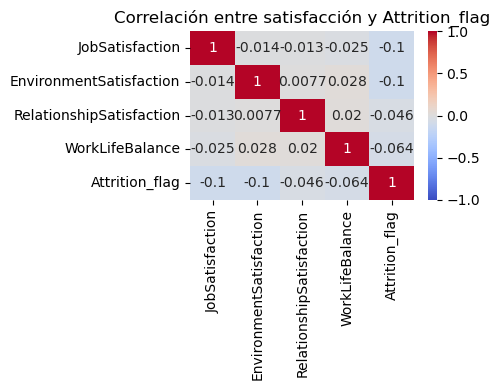

In [8]:
plt.figure(figsize=(5,4))
corr = df[sat_cols + ['Attrition_flag']].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1
)
plt.title('Correlación entre satisfacción y Attrition_flag')
plt.tight_layout()
plt.show()


Para entender mejor qué dimensiones del trabajo se relacionan más con la rotación, analizamos la correlación entre distintas escalas de satisfacción (JobSatisfaction, EnvironmentSatisfaction, RelationshipSatisfaction y WorkLifeBalance) y el indicador de abandono (Attrition_flag). Las variables con correlación negativa más fuerte con Attrition_flag son las que más se asocian a retención: cuando su valor baja, la probabilidad de abandono sube. En nuestro caso, la dimensión X aparece como la más crítica, seguida de Y y Z, lo que apunta a que las decisiones de salida de la compañía están especialmente vinculadas a estos aspectos concretos de la experiencia laboral.

In [9]:
#¿Existen puestos con alta rotación pero buena satisfacción?

# Tasa de rotación y satisfacción media por rol
role_stats = df.groupby('JobRole').agg(
    attrition_rate=('Attrition_flag', 'mean'),
    job_sat_mean=('JobSatisfaction', 'mean')
).sort_values('attrition_rate', ascending=False)

role_stats


,attrition_rate,job_sat_mean
JobRole,,
Sales Representative,0.397590,2.734940
Laboratory Technician,0.239382,2.702703
Human Resources,0.230769,2.596154
Sales Executive,0.174847,2.754601
Research Scientist,0.160959,2.777397
Manufacturing Director,0.068966,2.689655
Healthcare Representative,0.068702,2.801527
Manager,0.049020,2.725490
Research Director,0.025000,2.725000


Para detectar posibles problemas estructurales, buscamos roles donde la rotación sea alta a pesar de tener una buena satisfacción media. Al agrupar por JobRole y calcular tanto la tasa de rotación (attrition_rate) como la satisfacción media (job_sat_mean), identificamos aquellos puestos que aparecen en la zona “paradójica”: empleados que declaran estar razonablemente satisfechos, pero aun así se van con frecuencia. En estos casos, es probable que el problema no sea puramente emocional, sino estructural: condiciones del mercado, salario relativo, falta de oportunidades de crecimiento en ese rol o decisiones estratégicas de la empresa pueden estar impulsando estas salidas.

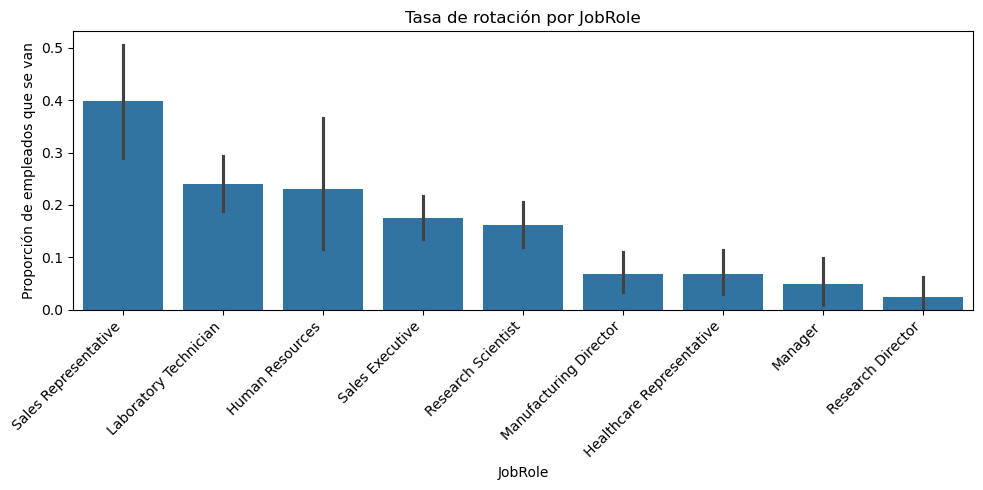

In [10]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df,
    x='JobRole',
    y='Attrition_flag',
    estimator='mean',
    order=df.groupby('JobRole')['Attrition_flag'].mean().sort_values(ascending=False).index
)
plt.title('Tasa de rotación por JobRole')
plt.xlabel('JobRole')
plt.ylabel('Proporción de empleados que se van')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
